Import required libraries

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")
print("Path to dataset files:", path)

C:\Users\spars\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████████████████████████████████████████| 5.21k/5.21k [00:00<00:00, 1.12MB/s]

Extracting files...
Path to dataset files: C:\Users\spars\.cache\kagglehub\datasets\rohan0301\unsupervised-learning-on-country-data\versions\2


In [4]:
df = pd.read_csv(os.path.join(path, "Country-data.csv"))
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
# ==========================
# Dataset Overview
# ==========================

print("=" * 50)
print("Dataset Shape:")
print(df.shape)

print("\n" + "=" * 50)
print("Column Names:")
print(df.columns.tolist())

print("\n" + "=" * 50)
print("Data Types:")
print(df.dtypes)

print("\n" + "=" * 50)
print("Statistical Summary:")
display(df.describe().T)

Dataset Shape:
(167, 10)

Column Names:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Data Types:
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


# Dataset Overview
Before performing clustering, it is essential to understand the dataset. In above section, we examine the dataset's dimensions, feature names, data types, and summary statistics to verify data quality and identify the characteristics of each variable.

**Key observations to make:**
- The dataset contains **167 countries** and **10 features**.
- `country` is the only categorical feature; all others are numerical.
- Features such as **income** and **gdpp** have much larger ranges than the remaining variables.
- Feature scaling will be required before applying K-Means and DBSCAN.

In [6]:
# ==========================
# Data Quality Check
# ==========================

print("=" * 50)
print("Missing Values:")
display(df.isnull().sum().to_frame(name="Missing Values"))

print("\n" + "=" * 50)
print("Duplicate Rows:", df.duplicated().sum())

print("\n" + "=" * 50)
print("Unique Countries:", df["country"].nunique())

Missing Values:


,Missing Values
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0



Duplicate Rows: 0

Unique Countries: 167


### Observations
- No missing values are present in the dataset.
- No duplicate records were found.
- All 167 countries are unique, indicating no repeated entries.

# Exploratory Data Analysis (EDA)

In this section, we explore the distribution of numerical features to understand their spread, identify potential outliers, and gain initial insights before applying clustering algorithms.

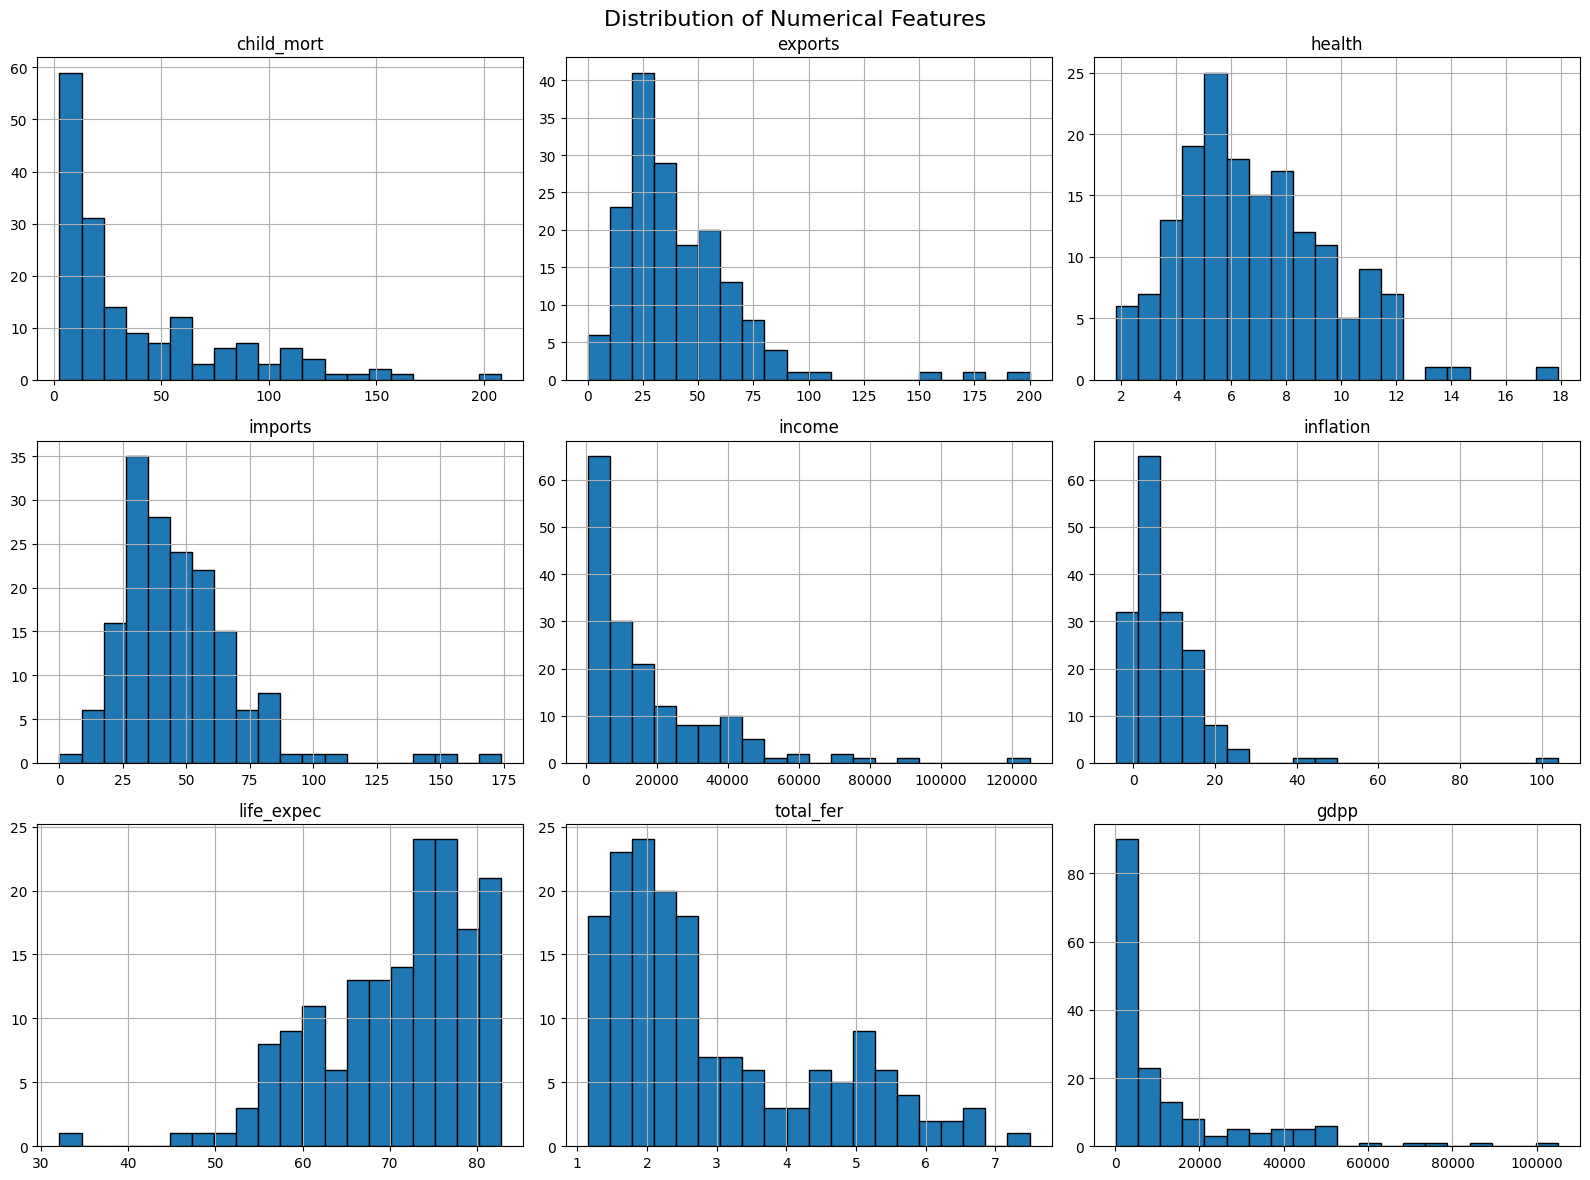

In [7]:
# ==========================
# Distribution of Numerical Features
# ==========================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observations
- Most numerical features are **right-skewed**, indicating that a few countries have significantly higher values than the majority.
- **Income** and **GDP per capita** show the highest variability with a long right tail.
- **Child mortality** and **inflation** also exhibit noticeable skewness, suggesting the presence of extreme values.
- **Life expectancy** is comparatively less skewed and is concentrated between **60–80 years**.
- Since the features have different distributions and scales, **standardization is required** before clustering.

# Outlier Analysis

This section examines the presence of outliers in the numerical features using boxplots. Identifying outliers helps assess their potential impact on clustering algorithms.

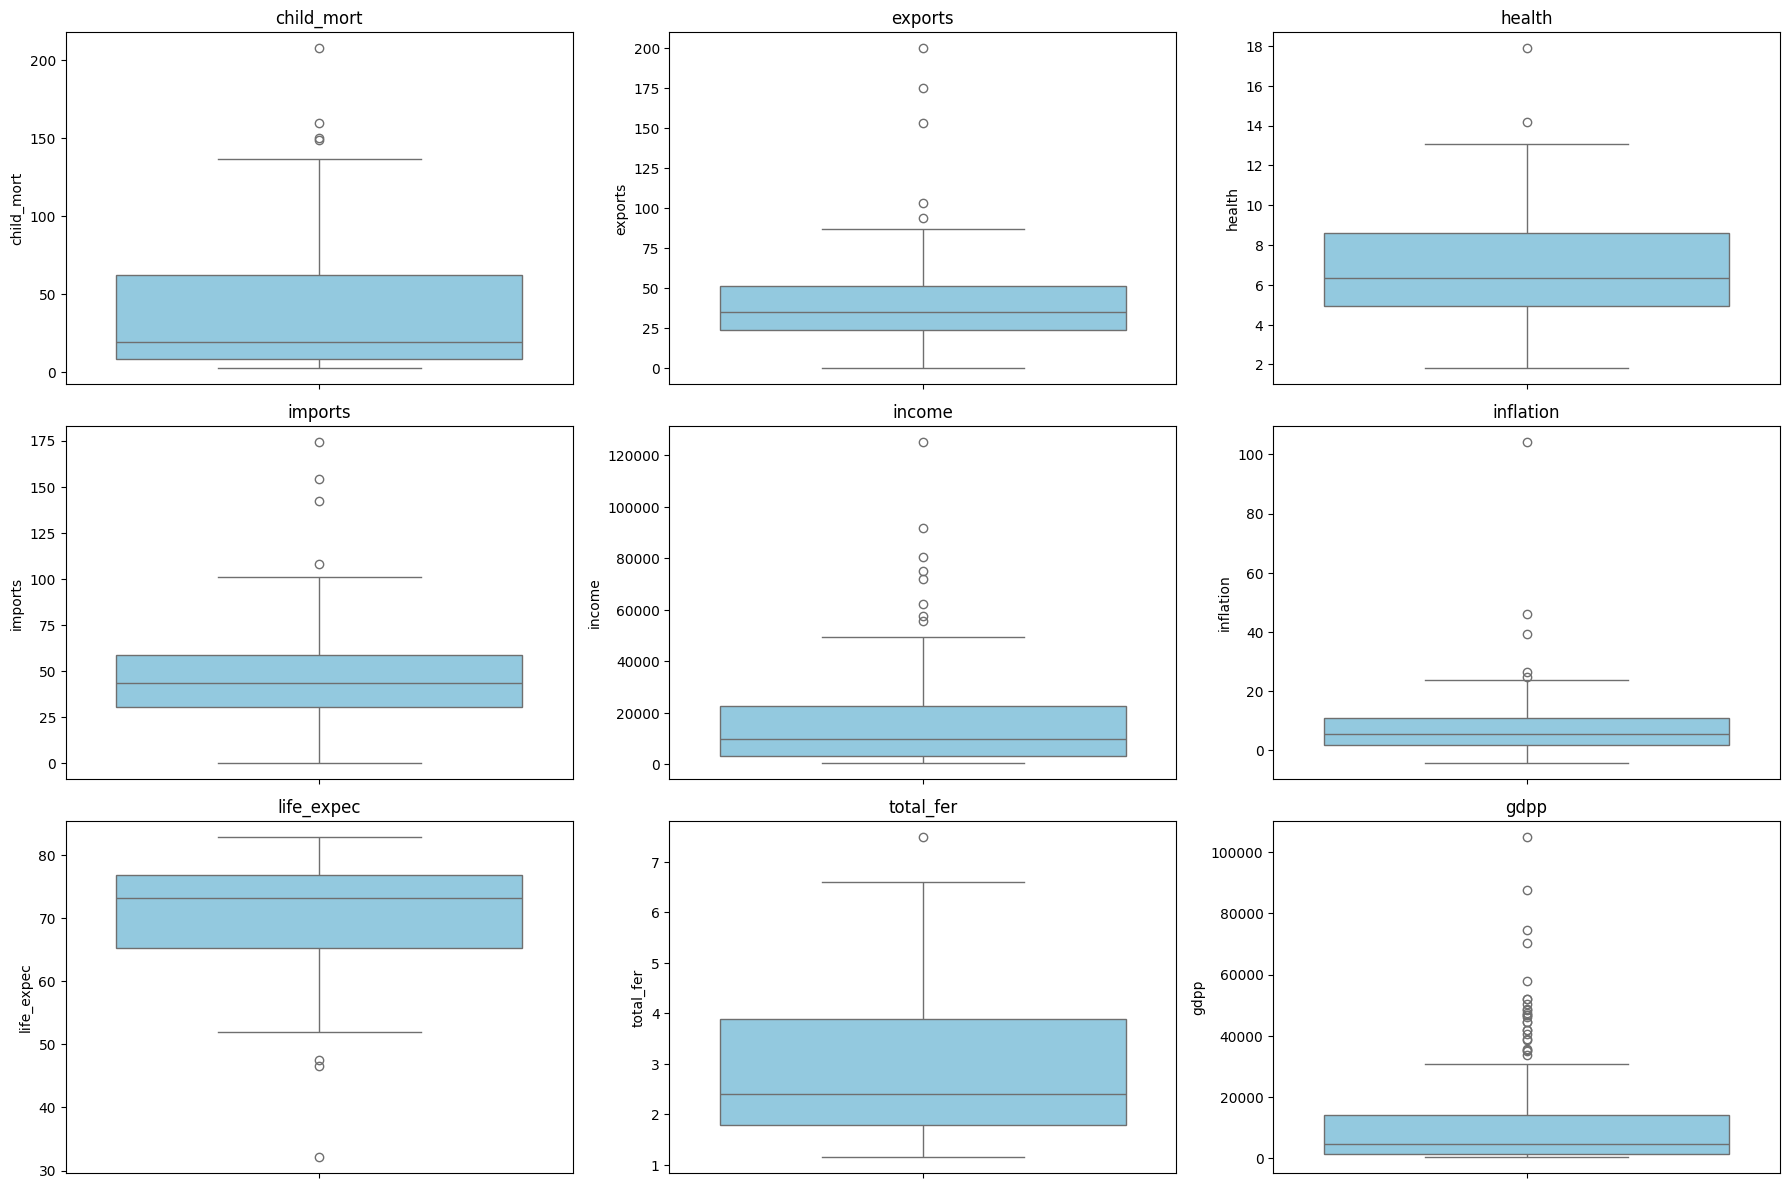

In [8]:
# ==========================
# Outlier Analysis
# ==========================

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

### Observations
- Most numerical features contain outliers, particularly **income**, **gdpp**, **child_mort**, **exports**, and **inflation**.
- The detected outliers likely represent genuine differences in countries' socio-economic conditions rather than data errors.
- Since these values are meaningful for the analysis, **no outliers will be removed**.
- The features will be **standardized** before clustering to reduce the influence of different scales.

# Correlation Analysis

This section analyzes the relationships between numerical features using a correlation heatmap. Understanding feature correlations helps interpret the data and provides insights into how socio-economic and health indicators are related.

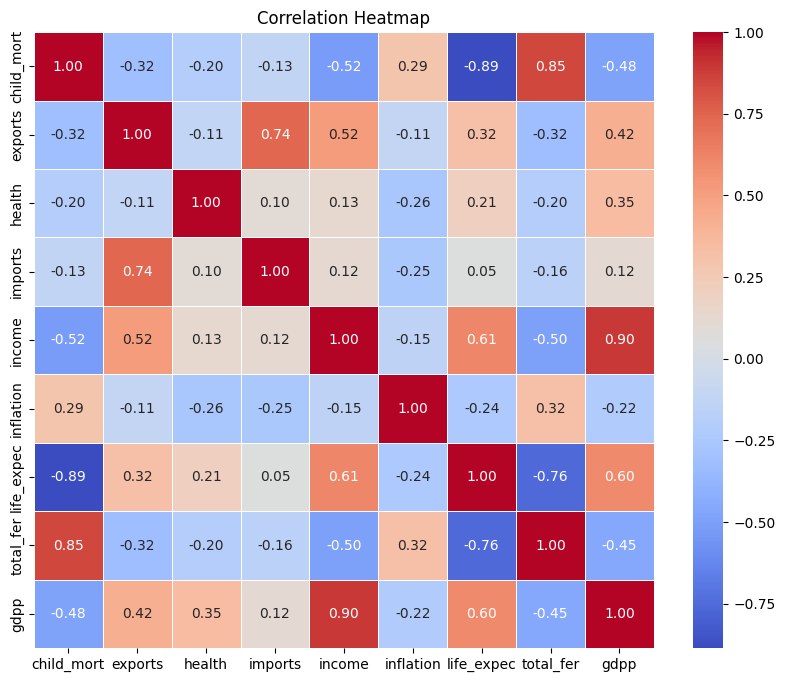

In [9]:
# ==========================
# Correlation Analysis
# ==========================

plt.figure(figsize=(10, 8))

sns.heatmap(
    df.drop(columns="country").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observations
- **Income** and **GDP per capita** are strongly positively correlated (**0.90**), indicating that wealthier countries generally have higher GDP per capita.
- **Child mortality** is strongly negatively correlated with **life expectancy** (**-0.89**) and positively correlated with **total fertility** (**0.85**).
- **Exports** and **imports** show a strong positive correlation (**0.74**), reflecting interconnected trade activities.
- The observed correlations align with real-world socio-economic relationships, so **all features will be retained** for clustering.

# Feature Scaling

Since the numerical features have different units and scales, they are standardized using `StandardScaler`. This ensures that each feature contributes equally to the distance calculations used by clustering algorithms.

In [10]:
# ==========================
# Feature Scaling
# ==========================

# Store country names separately
countries = df["country"]

# Select numerical features
X = df.drop(columns="country")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first five rows
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Observations
- All numerical features have been standardized using `StandardScaler`.
- The transformed features are centered around **0** with a similar scale.
- Standardization ensures that no single feature dominates the distance calculations during clustering.
- The scaled dataset is now ready for K-Means and DBSCAN.

# Finding the Optimal Number of Clusters

The Elbow Method is used to determine the optimal number of clusters (`K`) by analyzing the Within-Cluster Sum of Squares (WCSS). The point where the decrease in WCSS starts to slow down is considered the optimal value of `K`.

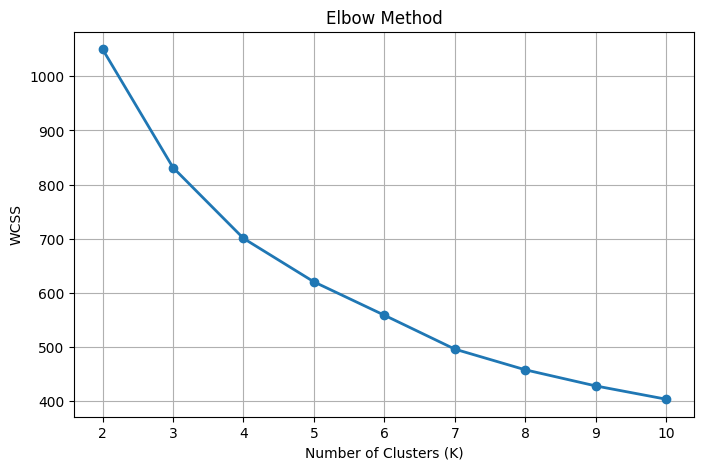

In [11]:
# ==========================
# Elbow Method
# ==========================

wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(range(2,11))
plt.grid(True)

plt.show()

### Observations
- WCSS decreases as the number of clusters increases.
- A noticeable bend is observed around **K = 3–4**, suggesting a suitable range for the optimal number of clusters.
- The final value of **K** will be selected after evaluating the Silhouette Score.

# Silhouette Analysis

The Silhouette Score measures how well-separated the clusters are. A higher score indicates better-defined and more compact clusters. This metric is used alongside the Elbow Method to select the optimal number of clusters.

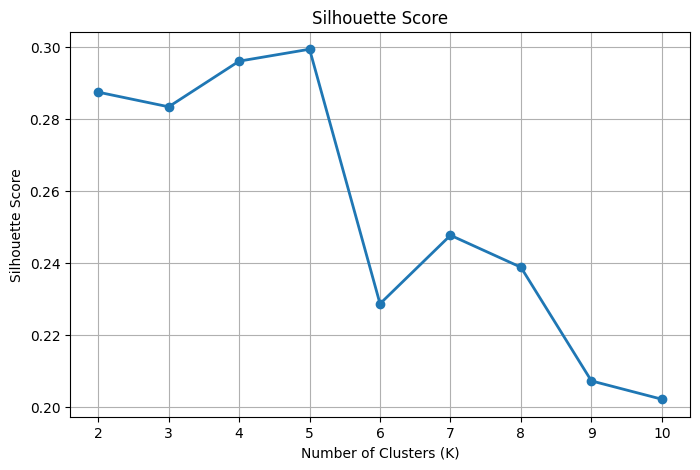

,K,Silhouette Score
0,2,0.287357
1,3,0.283296
2,4,0.295952
3,5,0.299259
4,6,0.228692
5,7,0.247681
6,8,0.238811
7,9,0.207312
8,10,0.202230


In [12]:
# ==========================
# Silhouette Score
# ==========================

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o', linewidth=2)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2,11))
plt.grid(True)

plt.show()

# Display scores
pd.DataFrame({
    "K": range(2,11),
    "Silhouette Score": silhouette_scores
})

### Observations
- The highest Silhouette Score is obtained for **K = 5 (0.2993)**, while **K = 4 (0.2960)** performs almost equally well.
- The Elbow Method indicates a clear bend around **K = 4**.
- Considering both metrics, **K = 4** is selected as the optimal number of clusters.

# K-Means Clustering

Based on the Elbow Method and Silhouette Analysis, K-Means clustering is performed with **4 clusters** to categorize countries according to their socio-economic and health indicators.

In [13]:
# ==========================
# K-Means Clustering
# ==========================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df[["country", "Cluster"]].head()

,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


# Cluster Distribution

This section examines the number of countries assigned to each cluster to understand the distribution of the clustering results.

,Number of Countries
Cluster,
0,32
1,47
2,85
3,3


C:\Users\spars\AppData\Local\Temp\ipykernel_19108\418423204.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


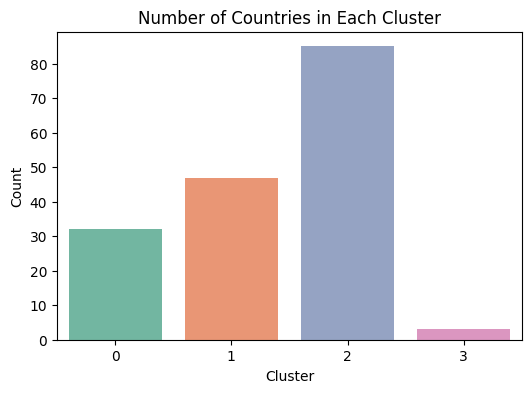

In [14]:
# ==========================
# Cluster Distribution
# ==========================

cluster_counts = df["Cluster"].value_counts().sort_index()

display(cluster_counts.to_frame(name="Number of Countries"))

plt.figure(figsize=(6,4))

sns.countplot(
    x="Cluster",
    data=df,
    palette="Set2"
)

plt.title("Number of Countries in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")

plt.show()

### Observations
- The countries are distributed across **4 clusters** with varying cluster sizes.
- **Cluster 2** contains the highest number of countries (**85**), while **Cluster 3** contains the fewest (**3**).
- The small size of Cluster 3 suggests it may represent a group of countries with distinct socio-economic characteristics.

# Cluster Profiling

To understand the characteristics of each cluster, the mean values of all numerical features are calculated. This helps identify the socio-economic and health profile of each group of countries.

In [15]:
# ==========================
# Cluster Profiling
# ==========================

cluster_profile = df.groupby("Cluster").mean(numeric_only=True).round(2)

display(cluster_profile)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67


### Observations
- **Cluster 1** has the highest child mortality, lowest income and GDP, lowest life expectancy, and highest fertility rate, indicating the **least developed countries**.
- **Cluster 0** represents developed countries with high income, high GDP, low child mortality, and high life expectancy.
- **Cluster 2** represents developing countries with moderate socio-economic and health indicators.
- **Cluster 3** consists of a small group of exceptionally wealthy countries with the highest income, GDP, and trade activity.

# Cluster Profile Visualization

The average values of each feature are visualized across clusters to better understand the socio-economic and health characteristics of each group.

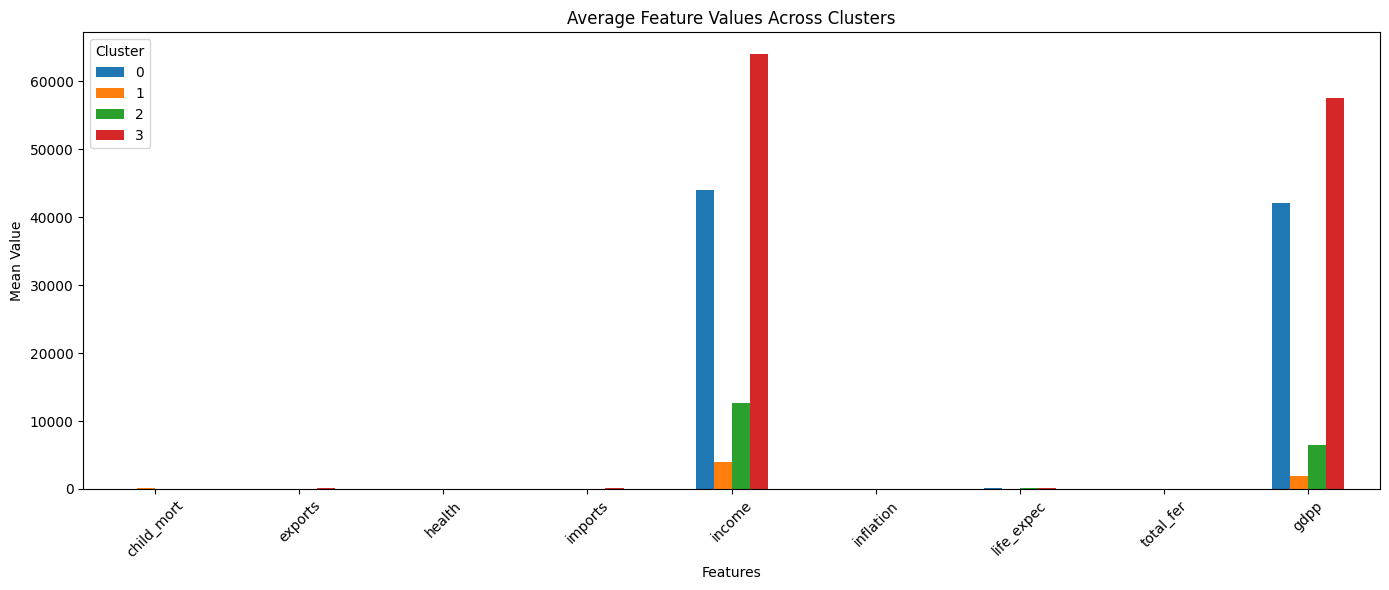

In [16]:
# ==========================
# Cluster Profile Visualization
# ==========================

cluster_profile.T.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Average Feature Values Across Clusters")
plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

### Observations
- The cluster profiles show clear differences in socio-economic and health indicators across the four clusters.
- Cluster 1 consistently exhibits the weakest development indicators, while Clusters 0 and 3 represent economically stronger countries.
- The large magnitude of **income** and **GDP per capita** dominates the visualization, making smaller-scale features less distinguishable.

Based on the cluster profiling results, **Cluster 1** should be prioritized for financial assistance. Countries in this cluster exhibit the highest child mortality, lowest income and GDP per capita, lowest life expectancy, and highest fertility and inflation rates. These characteristics indicate the greatest socio-economic and healthcare challenges, making Cluster 1 the most suitable target for HELP International's aid program.

In [18]:
# ==========================
# Priority Score Calculation
# ==========================

priority = df[df["Cluster"] == 1].copy()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

priority["child_mort_scaled"] = scaler.fit_transform(priority[["child_mort"]])

priority["income_scaled"] = 1 - scaler.fit_transform(priority[["income"]])

priority["gdpp_scaled"] = 1 - scaler.fit_transform(priority[["gdpp"]])

priority["life_expec_scaled"] = 1 - scaler.fit_transform(priority[["life_expec"]])

# Weighted Priority Score
priority["Priority Score"] = (
    0.40 * priority["child_mort_scaled"] +
    0.25 * priority["income_scaled"] +
    0.20 * priority["gdpp_scaled"] +
    0.15 * priority["life_expec_scaled"]
)

priority = priority.sort_values(
    by="Priority Score",
    ascending=False
)

priority[
    [
        "country",
        "Priority Score",
        "child_mort",
        "income",
        "gdpp",
        "life_expec"
    ]
].head(20)

,country,Priority Score,child_mort,income,gdpp,life_expec
66,Haiti,0.988159,208.0,1500,662,32.1
31,Central African Republic,0.798181,149.0,888,446,47.5
132,Sierra Leone,0.793100,160.0,1220,399,55.0
32,Chad,0.752684,150.0,1930,897,56.5
97,Mali,0.713448,137.0,1870,708,59.5
112,Niger,0.695658,123.0,814,348,58.8
37,"Congo, Dem. Rep.",0.686008,116.0,609,334,57.5
64,Guinea-Bissau,0.680214,114.0,1390,547,55.6
25,Burkina Faso,0.675409,116.0,1430,575,57.9
87,Lesotho,0.666917,99.7,2380,1170,46.5


### Observations
- The Priority Score successfully ranks countries within the most vulnerable cluster based on multiple socio-economic indicators.
- Haiti has the highest Priority Score, followed by the Central African Republic and Sierra Leone.
- These countries should be considered the highest priority for HELP International's aid allocation.

# DBSCAN Clustering

In addition to K-Means, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is applied to identify clusters based on data density. Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand and can also detect noise (outlier) points.

In [20]:
# ==========================
# DBSCAN Clustering
# ==========================

from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

# Display cluster distribution
dbscan_counts = df["DBSCAN_Cluster"].value_counts().sort_index()

display(dbscan_counts.to_frame(name="Number of Countries"))

,Number of Countries
DBSCAN_Cluster,
-1,30
0,137


### Observations
- DBSCAN identified one major cluster containing **137 countries**.
- **30 countries** were classified as noise (`-1`), indicating that they do not belong to any dense cluster.
- Compared to K-Means, DBSCAN produced fewer clusters and was able to identify outlier countries.

# PCA Visualization

Principal Component Analysis (PCA) is used to reduce the dataset to two dimensions, allowing the K-Means clusters to be visualized while preserving the maximum possible variance.

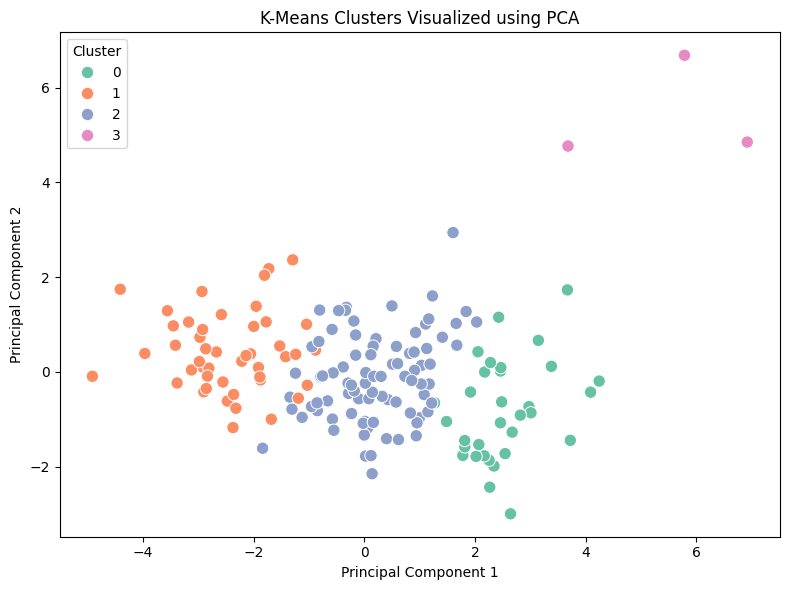

In [21]:
# ==========================
# PCA Visualization
# ==========================

from sklearn.decomposition import PCA

# Reduce data to two principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for visualization
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("K-Means Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Observations
- The PCA plot shows that the four K-Means clusters are reasonably well separated.
- Cluster 3 is clearly isolated, indicating countries with distinct socio-economic characteristics.
- Some overlap exists between Clusters 0 and 2 due to the dimensionality reduction from 9 features to 2 principal components.

# Conclusion

The countries were successfully grouped into four clusters using K-Means based on socio-economic and health indicators.

- **Cluster 1** represents the least developed countries, characterized by high child mortality, low income, low GDP per capita, low life expectancy, and high fertility rates.
- **Cluster 0** represents developed countries with strong economic and health indicators.
- **Cluster 2** represents developing countries with moderate socio-economic conditions.
- **Cluster 3** contains a small group of exceptionally wealthy countries with the highest income, GDP per capita, and trade activity.

To further prioritize aid distribution, a **Priority Score** was developed using child mortality, income, GDP per capita, and life expectancy. Based on this ranking, countries such as **Haiti, Central African Republic, Sierra Leone, and Chad** emerged as the highest-priority candidates for financial assistance.

Overall, the analysis provides a data-driven framework to help **HELP International** identify and prioritize countries that require immediate humanitarian support.